Mounted at /content/drive
TOTAL: 579
Distribution: Counter({np.int64(0): 150, np.int64(3): 150, np.int64(2): 147, np.int64(1): 132})

Train: Counter({np.int64(0): 105, np.int64(3): 105, np.int64(2): 103, np.int64(1): 92})
Val: Counter({np.int64(3): 23, np.int64(2): 22, np.int64(0): 22, np.int64(1): 20})
Test: Counter({np.int64(0): 23, np.int64(3): 22, np.int64(2): 22, np.int64(1): 20})


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

...

Epoch 10 | Train Loss: 0.6558 | Val Acc: 0.6092


100%|██████████| 102/102 [00:37<00:00,  2.69it/s]


Epoch 11 | Train Loss: 0.6626 | Val Acc: 0.6207


100%|██████████| 102/102 [00:37<00:00,  2.69it/s]


Epoch 12 | Train Loss: 0.6063 | Val Acc: 0.6552

===== TEST CLASSIFICATION REPORT =====

              precision    recall  f1-score   support

     neutral       0.42      0.78      0.55        23
       happy       0.44      0.40      0.42        20
         sad       1.00      0.50      0.67        22
       angry       0.80      0.55      0.65        22

    accuracy                           0.56        87
   macro avg       0.67      0.56      0.57        87
weighted avg       0.67      0.56      0.57        87



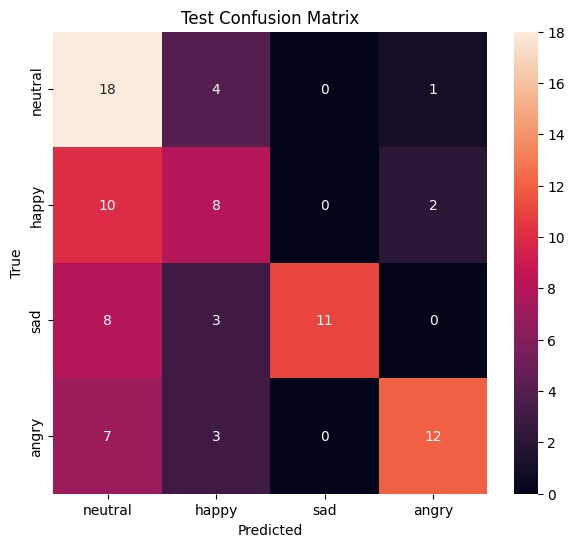

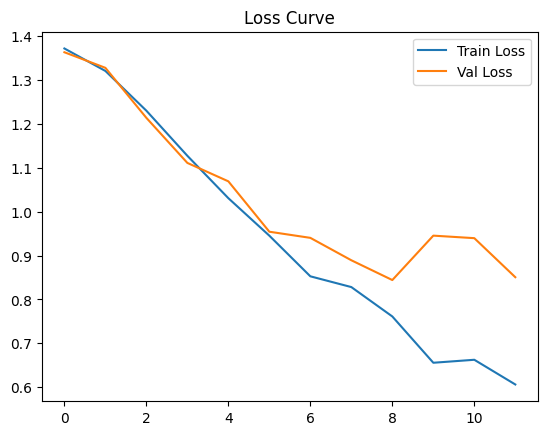

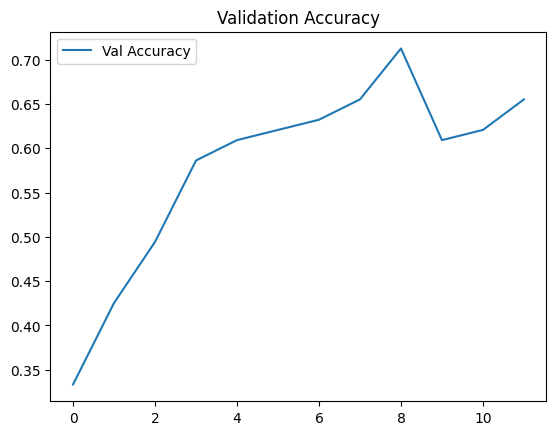

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# ================= INSTALL =================
!pip install -q transformers torch librosa scikit-learn tqdm

# ================= IMPORTS =================
import os
import numpy as np
import torch
import librosa
from tqdm import tqdm
from collections import Counter

from transformers import Wav2Vec2Processor, Wav2Vec2Model

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

# ================= PATH =================
DATA_PATH = "/content/drive/MyDrive/SER_Project/"
EYASE_FOLDER = DATA_PATH + "EYASE/"

# ================= LABELS =================
EMOTION_LABELS = ["neutral", "happy", "sad", "angry"]
LABEL2IDX = {l:i for i,l in enumerate(EMOTION_LABELS)}

emotion_map_eyase = {
    "neu": "neutral",
    "hap": "happy",
    "sad": "sad",
    "ang": "angry"
}

# ================= AUDIO =================
def load_audio(file_path, sr=16000, max_len=5):
    audio, _ = librosa.load(file_path, sr=sr)
    max_samples = sr * max_len

    if len(audio) < max_samples:
        audio = np.pad(audio, (0, max_samples - len(audio)))
    else:
        audio = audio[:max_samples]

    return audio


def augment(audio):
    noise = np.random.randn(len(audio)) * 0.002
    return audio + noise


# ================= LOAD EYASE =================
def load_eyase(folder):
    X, y = [], []

    for root, _, files in os.walk(folder):
        for file in files:
            if file.endswith(".wav"):

                parts = file.split("_")
                if len(parts) < 2:
                    continue

                code = parts[1][:3].lower()
                label = emotion_map_eyase.get(code)

                if label in LABEL2IDX:
                    path = os.path.join(root, file)
                    X.append(load_audio(path))
                    y.append(LABEL2IDX[label])

    return np.array(X, dtype=np.float32), np.array(y)


X, y = load_eyase(EYASE_FOLDER)

print("TOTAL:", len(X))
print("Distribution:", Counter(y))


# ================= SPLIT (TRAIN / VAL / TEST) =================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("\nTrain:", Counter(y_train))
print("Val:", Counter(y_val))
print("Test:", Counter(y_test))




In [ ]:
# ================= MODEL =================
MODEL_ID = "jonatasgrosman/wav2vec2-large-xlsr-53-english"
processor = Wav2Vec2Processor.from_pretrained(MODEL_ID)
base_model = Wav2Vec2Model.from_pretrained(MODEL_ID)


# ================= FREEZE + UNFREEZE =================
# Freeze everything first
for param in base_model.parameters():
    param.requires_grad = False

# UNFREEZE LAST 6 TRANSFORMER LAYERS
for layer in base_model.encoder.layers[-6:]:
    for param in layer.parameters():
        param.requires_grad = True


# ================= DATASET =================
class SERDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = X
        self.y = y
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        audio = self.X[idx]

        if self.augment and np.random.rand() < 0.4:
            audio = augment(audio)

        # inputs = processor(audio, sampling_rate=16000, return_tensors="pt")
        inputs = processor(audio, sampling_rate=16000, return_tensors="pt", padding=True)

        return inputs.input_values.squeeze(0), torch.tensor(self.y[idx])


train_ds = SERDataset(X_train, y_train, augment=True)
val_ds   = SERDataset(X_val, y_val)
test_ds  = SERDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=4)
test_loader  = DataLoader(test_ds, batch_size=4)


# ================= MODEL HEAD =================
class SERModel(nn.Module):
    def __init__(self, base_model, num_labels):
        super().__init__()

        self.wav2vec = base_model

        hidden_size = base_model.config.hidden_size  # 🔥 AUTO FIX

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_labels)
        )

    def forward(self, x):
        x = self.wav2vec(x).last_hidden_state
        x = x.mean(dim=1)
        return self.classifier(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SERModel(base_model, len(EMOTION_LABELS)).to(device)


# ================= LOSS =================
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)

In [ ]:
# ================= TRAIN =================
EPOCHS = 30

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(EPOCHS):

    # ===== TRAIN =====
    model.train()
    total_loss = 0
    correct, total = 0, 0

    for x, yb in tqdm(train_loader):
        x, yb = x.to(device), yb.to(device)

        optimizer.zero_grad()
        out = model(x)

        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(out, dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0
    correct, total = 0, 0

    with torch.no_grad():
        for x, yb in val_loader:
            x, yb = x.to(device), yb.to(device)

            out = model(x)
            loss = criterion(out, yb)
            val_loss += loss.item()

            preds = torch.argmax(out, dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print("-"*50)



100%|██████████| 102/102 [01:05<00:00,  1.56it/s]


Epoch 1
Train Loss: 0.8039 | Train Acc: 0.6889
Val   Loss: 0.9428 | Val   Acc: 0.6322
--------------------------------------------------


100%|██████████| 102/102 [01:04<00:00,  1.58it/s]


Epoch 2
Train Loss: 0.7884 | Train Acc: 0.6840
Val   Loss: 0.8638 | Val   Acc: 0.6207
--------------------------------------------------


100%|██████████| 102/102 [01:04<00:00,  1.58it/s]


...

100%|██████████| 102/102 [01:04<00:00,  1.58it/s]


Epoch 8
Train Loss: 0.6422 | Train Acc: 0.7877
Val   Loss: 0.8273 | Val   Acc: 0.6322
--------------------------------------------------


100%|██████████| 102/102 [01:04<00:00,  1.58it/s]


Epoch 9
Train Loss: 0.6706 | Train Acc: 0.7457
Val   Loss: 0.8586 | Val   Acc: 0.6667
--------------------------------------------------


  1%|          | 1/102 [00:00<01:07,  1.51it/s]

In [1]:
# ================= TEST EVALUATION =================
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for x, yb in test_loader:
        x = x.to(device)

        out = model(x)
        preds = torch.argmax(out, dim=1).cpu().numpy()

        y_true.extend(yb.numpy())
        y_pred.extend(preds)


print("\n===== TEST CLASSIFICATION REPORT =====\n")
print(classification_report(y_true, y_pred, target_names=EMOTION_LABELS))


# ================= CONFUSION MATRIX =================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=EMOTION_LABELS,
            yticklabels=EMOTION_LABELS)

plt.title("Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


# ================= CURVES =================
# ===== LOSS CURVE =====
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Train vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

# ===== ACCURACY CURVE =====
plt.figure(figsize=(8,5))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.legend()
plt.title("Train vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

NameError: name 'model' is not defined